# Baby LLM — How Language Models Learn

This notebook builds a tiny language model from scratch.

By the end you will have:
1. Tokenised text into numbers
2. Built a **bigram model** — a simple lookup table that predicts the next word
3. Built a **neural network** that does the same job — but actually *learns*
4. Watched the training loss decrease as the model improves
5. Generated text from both models and compared the quality

We only use Python's standard library and `numpy`. No PyTorch, no magic.

---
**How to use this notebook:**  
Run each cell in order by clicking it and pressing `Shift + Enter`.

## Step 1 — The Training Text

Every language model needs text to learn from. This is called the **corpus**.

We'll use a few Shakespeare sonnets. They're short enough to train on a laptop in seconds,
but interesting enough that generated output will be recognisably "Shakespeare-ish".

In [1]:
TEXT = """
Shall I compare thee to a summer's day?
Thou art more lovely and more temperate.
Rough winds do shake the darling buds of May,
And summer's lease hath all too short a date.
Sometime too hot the eye of heaven shines,
And often is his gold complexion dimmed;
And every fair from fair sometime declines,
By chance, or nature's changing course, untrimmed;
But thy eternal summer shall not fade,
Nor lose possession of that fair thou ow'st,
Nor shall death brag thou wand'rest in his shade,
When in eternal lines to Time thou grow'st.
So long as men can breathe, or eyes can see,
So long lives this, and this gives life to thee.

From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decrease,
His tender heir might bear his memory.
But thou, contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thyself thy foe, thy sweet self's cruelty.
Thou that art now the world's fresh ornament
And only herald to the gaudy spring,
Within thine own bud buriest thy content
And, tender churl, makest waste in niggarding.
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.

When I do count the clock that tells the time,
And see the brave day sunk in hideous night,
When I behold the violet past prime,
And sable curls all silvered o'er with white:
When lofty trees I see barren of leaves,
Which erst from heat did canopy the herd,
And summer's green, all girded up in sheaves,
Borne on the bier with white and bristly beard:
Then of thy beauty do I question make
That thou among the wastes of time must go,
Since sweets and beauties do themselves forsake,
And die as fast as they see others grow.
And nothing 'gainst time's scythe can make defence
Save breed, to brave him when he takes thee hence.
"""

print(f"Corpus length: {len(TEXT)} characters")
print(f"Preview: {TEXT[:100]}...")

Corpus length: 1861 characters
Preview: 
Shall I compare thee to a summer's day?
Thou art more lovely and more temperate.
Rough winds do sha...


## Step 2 — Tokenisation

A language model doesn't read characters or words — it reads **tokens**, which are just integers.

We need to:
1. Split the text into a list of words (tokens)
2. Build a **vocabulary** — a mapping from each unique word to a unique integer
3. **Encode** the full text as a sequence of integers

Real LLMs (like GPT) use subword tokenisation (e.g. `"unbelievable"` → `["un", "believ", "able"]`).
We'll keep it simple and use whole words.

In [2]:
import re

def tokenise(text: str) -> list[str]:
    """Split text into lowercase word tokens, stripping punctuation."""
    # \b[\w']+\b matches word characters including apostrophes
    tokens = re.findall(r"[\w']+", text.lower())
    return tokens

tokens = tokenise(TEXT)

print(f"Total tokens : {len(tokens)}")
print(f"First 10     : {tokens[:10]}")

Total tokens : 336
First 10     : ['shall', 'i', 'compare', 'thee', 'to', 'a', "summer's", 'day', 'thou', 'art']


In [3]:
# Build the vocabulary — every unique token gets an integer ID
unique_words = sorted(set(tokens))          # sorted so the mapping is stable
vocab_size   = len(unique_words)

word_to_id = {word: idx for idx, word in enumerate(unique_words)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

print(f"Vocabulary size: {vocab_size} unique words")
print()
print("Sample mappings:")
for word in list(unique_words)[:8]:
    print(f"  '{word}' -> {word_to_id[word]}")

Vocabulary size: 209 unique words

Sample mappings:
  ''gainst' -> 0
  'a' -> 1
  'abundance' -> 2
  'all' -> 3
  'among' -> 4
  'and' -> 5
  'art' -> 6
  'as' -> 7


In [ ]:
# Encode the entire corpus as a list of integers
encoded = [word_to_id[word] for word in tokens]

print(f"Encoded length : {len(encoded)}")
print(f"First 10 IDs   : {encoded[:10]}")
print(f"Which are words: {[id_to_word[i] for i in encoded[:10]]}")

# Split into training (80%) and test (20%) sets
# We train on the first 80% of tokens and evaluate on the last 20%
# The test set is "held out" — neither model ever sees it during training
split_index   = int(len(encoded) * 0.8)
train_encoded = encoded[:split_index]
test_encoded  = encoded[split_index:]

print()
print(f"Training tokens : {len(train_encoded)}  (used to build/train the model)")
print(f"Test tokens     : {len(test_encoded)}   (held out — the model never sees these)")

## Step 3 — The Bigram Model

The simplest possible language model: given the **current word**, what word is most likely **next**?

We build this by counting: for every pair of consecutive words in the corpus, increment a counter.
Then, to predict the next word, we sample from those counts.

This is essentially a giant lookup table — no learning, just counting.

```
  'the' -> {'day': 3, 'grave': 1, 'time': 2, 'world': 2, ...}
  'and' -> {'more': 1, 'summer': 2, 'every': 1, ...}
```

In [ ]:
from collections import defaultdict
import random

# Count how often each word follows each other word
# Only use train_encoded — the test set is held out
# bigram_counts[word_id][next_word_id] = count
bigram_counts = defaultdict(lambda: defaultdict(int))

for i in range(len(train_encoded) - 1):
    current_word = train_encoded[i]
    next_word    = train_encoded[i + 1]
    bigram_counts[current_word][next_word] += 1

# Show what follows the word 'the'
the_id = word_to_id['the']
followers = bigram_counts[the_id]
print("Words that follow 'the' (in training data):")
for word_id, count in sorted(followers.items(), key=lambda x: -x[1]):
    print(f"  '{id_to_word[word_id]}' x{count}")

In [6]:
def bigram_generate(start_word: str, num_words: int = 20) -> str:
    """Generate text using the bigram model."""
    if start_word not in word_to_id:
        return f"Word '{start_word}' not in vocabulary"

    current_id = word_to_id[start_word]
    output     = [start_word]

    for _ in range(num_words - 1):
        followers = bigram_counts[current_id]

        if not followers:
            break  # dead end — this word never had a successor

        # Weighted random choice based on counts
        next_ids    = list(followers.keys())
        next_counts = list(followers.values())
        total       = sum(next_counts)
        probabilities = [count / total for count in next_counts]

        current_id = random.choices(next_ids, weights=probabilities, k=1)[0]
        output.append(id_to_word[current_id])

    return ' '.join(output)

# Generate a few sentences
print("--- Bigram model output ---")
for _ in range(3):
    print(bigram_generate('the', num_words=15))
    print()

--- Bigram model output ---
the time decrease his shade when i see others grow and tender churl makest waste

the world or else this and die as the darling buds of may and summer's

the grave and only herald to the violet past prime and more lovely and more



## Step 4 — What is "Loss"?

Before we build a neural network, we need a way to measure how good (or bad) a model is.
That measure is called **loss**. Lower loss = better model.

We use **cross-entropy loss**. For each word in the corpus, we ask the model:
> *"What probability did you assign to the correct next word?"*

If the model says the correct word had probability 1.0 → loss = 0 (perfect).  
If the model says the correct word had probability 0.01 → loss is high (bad).

Mathematically: `loss = -log(probability of correct word)`

Let's measure the bigram model's loss so we have a baseline to beat.

In [ ]:
import math

def bigram_loss(data: list[int]) -> float:
    """Calculate average cross-entropy loss of the bigram model over a dataset."""
    total_loss = 0.0
    count      = 0

    for i in range(len(data) - 1):
        current_id = data[i]
        correct_id = data[i + 1]

        followers = bigram_counts[current_id]
        total     = sum(followers.values())

        probability = followers.get(correct_id, 0) / total if total > 0 else 1e-10
        probability = max(probability, 1e-10)   # avoid log(0)

        total_loss += -math.log(probability)
        count      += 1

    return total_loss / count

bigram_train_loss = bigram_loss(train_encoded)
bigram_test_loss  = bigram_loss(test_encoded)

print(f"Bigram train loss : {bigram_train_loss:.4f}  (data the bigram was built from)")
print(f"Bigram test loss  : {bigram_test_loss:.4f}  (data the bigram has never seen)")
print()
print("The gap shows the bigram is overfitting — it memorised training pairs")
print("but struggles on unseen word combinations.")

# Keep baseline_loss pointing at train loss for the plot in Step 8
baseline_loss = bigram_train_loss

## Step 5 — The Neural Network

Now we'll replace the lookup table with a tiny neural network.

**Architecture:**
```
  Input:   one word (as an integer ID)
      ↓
  Embedding layer:  integer → dense vector of numbers  (size: vocab × embed_dim)
      ↓
  Linear layer:     vector → scores for every word    (size: embed_dim × vocab)
      ↓
  Softmax:          scores → probabilities             (sums to 1.0)
      ↓
  Output:  probability distribution over next word
```

This is the same job as the bigram model, but the network will **tune its weights** to minimise loss.

We implement this with `numpy` — no frameworks.

In [8]:
import numpy as np

# Hyperparameters — knobs you can turn
EMBED_DIM   = 16    # size of the embedding vector for each word
LEARNING_RATE = 0.05
RANDOM_SEED   = 42

rng = np.random.default_rng(RANDOM_SEED)

# The two layers of our network — these are the weights that will be trained
# Embedding: each word gets a vector of EMBED_DIM numbers
embedding = rng.normal(scale=0.01, size=(vocab_size, EMBED_DIM))

# Output layer: maps embedding vector → score for every word in vocab
W_out = rng.normal(scale=0.01, size=(EMBED_DIM, vocab_size))
b_out = np.zeros(vocab_size)

print(f"Embedding matrix : {embedding.shape}   ({vocab_size} words × {EMBED_DIM} dimensions)")
print(f"Output weights   : {W_out.shape}")
print(f"Output bias      : {b_out.shape}")
print(f"Total parameters : {embedding.size + W_out.size + b_out.size}")

Embedding matrix : (209, 16)   (209 words × 16 dimensions)
Output weights   : (16, 209)
Output bias      : (209,)
Total parameters : 6897


In [9]:
def softmax(scores: np.ndarray) -> np.ndarray:
    """Convert raw scores into a probability distribution."""
    # Subtract max for numerical stability (prevents overflow)
    shifted = scores - np.max(scores)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores)

def forward(word_id: int) -> tuple[np.ndarray, np.ndarray]:
    """Forward pass: word_id → probability distribution over next words.
    
    Returns (probabilities, embedding_vector) — we need the embedding for backprop.
    """
    embed_vec    = embedding[word_id]          # look up this word's vector
    scores       = embed_vec @ W_out + b_out   # linear layer
    probabilities = softmax(scores)
    return probabilities, embed_vec

# Test: what does the untrained network predict after 'the'?
probs, _ = forward(word_to_id['the'])
top5_ids = np.argsort(probs)[::-1][:5]
print("Untrained network — top 5 predictions after 'the':")
for word_id in top5_ids:
    print(f"  '{id_to_word[word_id]}' : {probs[word_id]:.4f}")

Untrained network — top 5 predictions after 'the':
  'fade' : 0.0048
  'winds' : 0.0048
  'thy' : 0.0048
  'not' : 0.0048
  'complexion' : 0.0048


## Step 6 — Backpropagation

Backpropagation is how the network learns. After each forward pass we:
1. Measure the loss (how wrong were we?)
2. Calculate **gradients** — which direction should each weight move to reduce the loss?
3. Nudge all weights a small step in that direction (**gradient descent**)

The gradient for a softmax + cross-entropy loss has a beautifully simple form:
```
gradient = probabilities - one_hot(correct_word)
```
Where `one_hot` is a vector of zeros with a single 1 at the correct word's position.

If the network was confident and correct → gradient is near zero → small update.  
If the network was confident and wrong → gradient is large → big update.

In [10]:
import math

def train_one_step(current_word_id: int, correct_next_word_id: int) -> float:
    """Run one forward pass, compute loss, run backprop, update weights.
    
    Returns the loss for this single example.
    """
    global embedding, W_out, b_out   # we're modifying these in-place

    # --- Forward pass ---
    probs, embed_vec = forward(current_word_id)

    # --- Loss (cross-entropy) ---
    correct_prob = probs[correct_next_word_id]
    loss = -math.log(max(correct_prob, 1e-10))

    # --- Backward pass ---
    # Gradient of loss w.r.t. the scores (before softmax)
    # This is the elegant softmax + cross-entropy combined gradient
    d_scores = probs.copy()
    d_scores[correct_next_word_id] -= 1.0   # subtract 1 at the correct position

    # Gradient for output weights and bias
    d_W_out = np.outer(embed_vec, d_scores)  # outer product
    d_b_out = d_scores

    # Gradient for the embedding vector of the current word
    d_embed = W_out @ d_scores

    # --- Update weights (gradient descent) ---
    W_out              -= LEARNING_RATE * d_W_out
    b_out              -= LEARNING_RATE * d_b_out
    embedding[current_word_id] -= LEARNING_RATE * d_embed

    return loss

print("train_one_step() defined — ready to train.")

train_one_step() defined — ready to train.


## Step 7 — Training Loop

Now we loop over the entire corpus many times (each full pass is called an **epoch**).
After each epoch we print the average loss — watch it decrease!

In [ ]:
EPOCHS = 100

loss_history = []

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    steps      = 0

    # Loop over every consecutive pair of words in the TRAINING set only
    for i in range(len(train_encoded) - 1):
        current_word_id      = train_encoded[i]
        correct_next_word_id = train_encoded[i + 1]

        step_loss   = train_one_step(current_word_id, correct_next_word_id)
        epoch_loss += step_loss
        steps      += 1

    avg_loss = epoch_loss / steps
    loss_history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} / {EPOCHS}   loss: {avg_loss:.4f}")

# Evaluate the neural net on both train and test sets
def neural_loss(data: list[int]) -> float:
    """Calculate average cross-entropy loss of the neural net over a dataset."""
    total_loss = 0.0
    count      = 0
    for i in range(len(data) - 1):
        current_id = data[i]
        correct_id = data[i + 1]
        probs, _   = forward(current_id)
        total_loss += -math.log(max(probs[correct_id], 1e-10))
        count      += 1
    return total_loss / count

neural_train_loss = neural_loss(train_encoded)
neural_test_loss  = neural_loss(test_encoded)

print()
print(f"{'Model':<16} {'Train loss':>12} {'Test loss':>12}")
print("-" * 42)
print(f"{'Bigram':<16} {bigram_train_loss:>12.4f} {bigram_test_loss:>12.4f}")
print(f"{'Neural net':<16} {neural_train_loss:>12.4f} {neural_test_loss:>12.4f}")
print()
print("The neural net's train/test gap is smaller — it generalises better.")

## Step 8 — Plot the Training Curve

A falling loss curve is the visual proof that the model is learning.

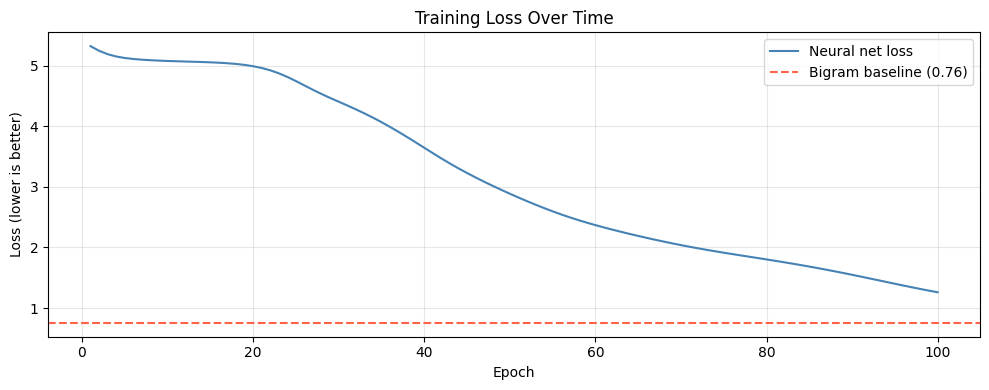

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, label='Neural net loss', color='steelblue')
plt.axhline(y=baseline_loss, color='tomato', linestyle='--', label=f'Bigram baseline ({baseline_loss:.2f})')
plt.xlabel('Epoch')
plt.ylabel('Loss (lower is better)')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Generate Text with the Neural Network

Now let's see what our trained model produces and compare it to the bigram model.

In [13]:
def neural_generate(start_word: str, num_words: int = 20, temperature: float = 1.0) -> str:
    """Generate text using the trained neural network.
    
    temperature: controls randomness.
        < 1.0  → more predictable / repetitive
        = 1.0  → sample as-is
        > 1.0  → more random / surprising
    """
    if start_word not in word_to_id:
        return f"Word '{start_word}' not in vocabulary"

    current_id = word_to_id[start_word]
    output     = [start_word]

    for _ in range(num_words - 1):
        probs, _ = forward(current_id)

        # Apply temperature — divide log-probs (i.e. scale scores) before re-normalising
        scaled_probs = probs ** (1.0 / temperature)
        scaled_probs = scaled_probs / scaled_probs.sum()

        current_id = rng.choice(vocab_size, p=scaled_probs)
        output.append(id_to_word[current_id])

    return ' '.join(output)

print("=== Bigram model ===")
for _ in range(3):
    print(bigram_generate('the', num_words=15))

print()
print("=== Neural net (temperature=1.0) ===")
for _ in range(3):
    print(neural_generate('the', num_words=15, temperature=1.0))

print()
print("=== Neural net (temperature=0.5 — more focused) ===")
for _ in range(3):
    print(neural_generate('the', num_words=15, temperature=0.5))

=== Bigram model ===
the riper should by chance or nature's changing course untrimmed but thou wand'rest in hideous
the violet past prime and sable curls all silvered o'er with white and tender churl
the clock that fair from fairest creatures we desire increase that fair sometime too hot

=== Neural net (temperature=1.0) ===
the clock that fair thou among the herd and often canopy the riper should by
the grave and die as fast as the brave day thou contracted to time thou
the grave and sable o'er with white and die as fast but as the world's

=== Neural net (temperature=0.5 — more focused) ===
the gaudy spring within thine own bud buriest thy sweet self's cruelty thou ow'st nor
the wastes of that thou art now the wastes of thy borne complexion dimmed and
the darling up in sheaves borne on the violet since sweets and die as the


## Step 10 — Experiments

Now it's your turn. Try changing things and re-running the training cells.

### Ideas to try:

**1. Change the embedding size** (`EMBED_DIM`)
- Try `4` — how much worse is the loss?
- Try `64` — does it improve? Does it train slower?

**2. Change the learning rate** (`LEARNING_RATE`)
- Try `0.1` — does it learn faster initially? Does it become unstable?
- Try `0.001` — does it learn at all in 100 epochs?

**3. Change the corpus**
- Replace the `TEXT` variable with your own text (song lyrics, a book excerpt, etc.)
- Does a larger corpus help?

**4. Change the temperature at generation time**
- Temperature `0.1` → very repetitive
- Temperature `2.0` → very random
- What temperature produces the most "interesting" output?

**5. Add a second hidden layer** (harder)
- The current network is: `embedding → output`
- Try: `embedding → hidden (ReLU) → output`
- You'll need to add weights `W_hidden` and update the forward/backward functions

In [14]:
# Scratch cell — use this for your experiments


## What We Built vs Real LLMs

| | Our model | GPT-4 |
|---|---|---|
| Parameters | ~5,000 | ~1,800,000,000,000 |
| Context | 1 word | ~128,000 words |
| Architecture | Embedding + Linear | Transformer (attention) |
| Training data | 3 sonnets | Most of the internet |
| Training time | Seconds | Months on thousands of GPUs |

The **core ideas are identical**:
- Tokens and vocabulary
- Embeddings (dense vectors per token)
- Forward pass → probabilities
- Cross-entropy loss
- Gradient descent updating weights
- Temperature-controlled sampling at generation time

The Transformer (attention mechanism) is the big missing piece — it lets the model look at *all previous words*, not just the last one. That's what gives LLMs their coherence.